In [4]:
import math, sys
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, rdDepictor, AllChem, rdMolDescriptors, Descriptors, Crippen
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator, AdditionalOutput
import mordred
from mordred import Calculator, descriptors
from rdkit.Chem.MolStandardize import rdMolStandardize
from IPython.display import SVG, display


import py3Dmol
from rdkit.Chem.Descriptors3D import (
    Asphericity, Eccentricity, InertialShapeFactor, NPR1, NPR2, PBF,
    PMI1, PMI2, PMI3, RadiusOfGyration, SpherocityIndex
)
from mordred.surface_area import SurfaceArea
from rdkit.Chem import ChemicalFeatures
from rdkit import RDConfig
import os
from collections import defaultdict

sys.path.append('../../')
sys.path.append('../')
# from utils_ import *
# from model import *

from data_utils_local.Generalised_data_utils import *
from data_utils_local.data_utils_smiles import *
from data_utils_local.graph_utils_smiles import *
from data_utils_local.compute_molecular_desc import *

%load_ext autoreload
%autoreload 2
# fix_seed(np_seed=20, torch_seed=30, random_seed=10)

In [5]:
smi = 'CCOC(=O)O'
# smi = 'c1ccccc1'
# smi = 'CON=C(C1=NSC(=N1)N)C(=O)NC2C3N(C2=O)C(=C(CS3)C[N+]45CCC(CC4)(CC5)C(=O)N)C(=O)[O-]'
# smi = 'NC(=O)OC[C@@H]1[C@H](NC(=O)/C(=N\OCC(=O)O)c2csc(N)n2)C(=O)N1S(=O)(=O)O'
# smi = 'CC(C)(N)CC(=O)N[C@@H]1CCc2ccccc2N(Cc2ccc(-c3ccccc3-c3nn[nH]n3)cc2)C1=O'
mol = Chem.MolFromSmiles(smi)
mol = Chem.AddHs(mol)
Chem.AssignStereochemistry(mol, force=True, cleanIt=True)

# 3D coordinates (optional)
try:
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)
    has_3d = True
except:
    has_3d = False

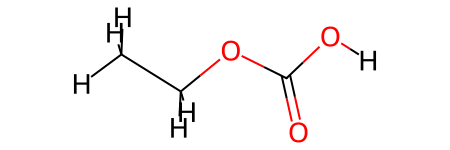

In [6]:
mol

## LogP and Molar Refractivity contribution

In [4]:
# symbols = [at.GetSymbol() for at in mol.GetAtoms()]
# crippen_logp = dict(zip(symbols, crippen_logp))
# crippen_mr = dict(zip(symbols, crippen_mr))
    
def logp_mr_contrib(mol):
    
    crippen = rdMolDescriptors._CalcCrippenContribs(mol)
    crippen_logp = [c[0] for c in crippen]
    crippen_mr = [c[1] for c in crippen]
    
    hydrophobic_centers = np.array([float(v > 0.0) for v in crippen_logp])
    atom_sasa = SurfaceArea.from_mol(mol).surface_area()
    atom_hydrophobicity = [s * lp for s,lp in zip(atom_sasa, crippen_logp)]
    
    return {'logP':np.array(crippen_logp), 'MR':np.array(crippen_mr), 'hypb_cntr':hydrophobic_centers, 'at_hyph':atom_hydrophobicity}

logp_mr_contrib(mol)

{'logP': array([ 0.1441, -0.2035, -0.0684, -0.2783,  0.4833, -0.2893,  0.123 ,
         0.123 ,  0.123 ,  0.123 ,  0.123 ,  0.298 ]),
 'MR': array([2.503 , 2.753 , 1.085 , 5.007 , 0.389 , 0.8238, 1.057 , 1.057 ,
        1.057 , 1.057 , 1.057 , 1.805 ]),
 'hypb_cntr': array([1., 0., 0., 0., 1., 0., 1., 1., 1., 1., 1., 1.]),
 'at_hyph': [2.462536216009697,
  -0.8307665648158242,
  -1.0140449933393594,
  -2.932799175326561,
  19.74453859825579,
  -11.234087822317612,
  2.794831955033184,
  2.5821816975850065,
  2.559397741429845,
  2.126502574481771,
  2.096123966274888,
  6.090416984370872]}

## Estate Indices

In [5]:
def estate_indices(mol):
    return {'estates':list(Chem.EState.EStateIndices(mol))}
estate_indices(mol)

{'estates': [-3.0960416666666672,
  -3.133796296296296,
  3.673611111111111,
  -1.6980324074074076,
  10.152152777777777,
  3.1800694444444444,
  6.567361111111111,
  6.567361111111111,
  6.567361111111111,
  6.7091666666666665,
  6.7091666666666665,
  5.968287037037037]}

## Partial charges

In [6]:
def gasteiger_charges(mol):
    
    Chem.rdPartialCharges.ComputeGasteigerCharges(mol)
    g_charge = []
    g_hcharge = []
    for atom in mol.GetAtoms():
        g_charge.append(float(atom.GetDoubleProp('_GasteigerCharge')))
        g_hcharge.append(float(atom.GetDoubleProp('_GasteigerHCharge')))
    
    return {'g_charge':g_charge, 'g_hcharge':g_hcharge}

gasteiger_charges(mol)

{'g_charge': [-0.030395123934245982,
  0.0921096229616778,
  -0.4347096514281998,
  0.5052459845257284,
  -0.20331766885398517,
  -0.44971760414632517,
  0.026511439271404577,
  0.026511439271404577,
  0.026511439271404577,
  0.07051758853756744,
  0.07051758853756744,
  0.3002149459860012],
 'g_hcharge': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}

## Accessible Surface Area

In [7]:
def atom_sasa(mol):
    sa_list = list(rdMolDescriptors._CalcLabuteASAContribs(mol)[0])
    return {'at_sasa':sa_list}

atom_sasa(mol)

{'at_sasa': [6.851892117295679,
  6.558985242916289,
  4.736862953800049,
  6.155365629538759,
  4.794537184071822,
  5.1088081911072125,
  1.3707585561702202,
  1.3707585561702202,
  1.3707585561702202,
  1.3707585561702202,
  1.3707585561702202,
  1.4311996572326342]}

## Topological Surface Area

In [8]:
def atom_tpsa(mol):
    tp_list = list(rdMolDescriptors._CalcTPSAContribs(mol))
    return {'at_tpsa':tp_list}

atom_tpsa(mol)

{'at_tpsa': [0.0, 0.0, 9.23, 0.0, 17.07, 20.23, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}

## Donor or Acceptor atom

In [9]:
def donor_or_acceptor(mol):
    
    acceptor_smarts_one = '[!$([#1,#6,F,Cl,Br,I,o,s,nX3,#7v5,#15v5,#16v4,#16v6,*+1,*+2,*+3])]'
    acceptor_smarts_two = "[$([O,S;H1;v2;!$(*-*=[O,N,P,S])]),$([O,S;H0;v2]),$([O,S;-]),$([N;v3;!$(N-*=[O,N,P,S])]),n&H0&+0,$([o,s;+0;!$([o,s]:n);!$([o,s]:c:n)])]"
    donor_smarts_one = "[$([N;!H0;v3,v4&+1]),$([O,S;H1;+0]),n&H1&+0]"
    donor_smarts_two = "[!$([#6,H0,-,-2,-3]),$([!H0;#7,#8,#9])]"
    results = np.zeros((mol.GetNumAtoms(), 2))

    hydrogen_donor_one = Chem.MolFromSmarts(donor_smarts_one)
    hydrogen_donor_two = Chem.MolFromSmarts(donor_smarts_two)
    hydrogen_acceptor_one = Chem.MolFromSmarts(acceptor_smarts_one)
    hydrogen_acceptor_two = Chem.MolFromSmarts(acceptor_smarts_two)

    hydrogen_donor_match_one = mol.GetSubstructMatches(hydrogen_donor_one)
    hydrogen_donor_match_two = mol.GetSubstructMatches(hydrogen_donor_two)
    hydrogen_donor_match = []
    hydrogen_donor_match.extend(hydrogen_donor_match_one)
    hydrogen_donor_match.extend(hydrogen_donor_match_two)
    hydrogen_donor_match = list(set(hydrogen_donor_match))

    hydrogen_acceptor_match_one = mol.GetSubstructMatches(hydrogen_acceptor_one)
    hydrogen_acceptor_match_two = mol.GetSubstructMatches(hydrogen_acceptor_two)
    hydrogen_acceptor_match = []
    hydrogen_acceptor_match.extend(hydrogen_acceptor_match_one)
    hydrogen_acceptor_match.extend(hydrogen_acceptor_match_two)
    hydrogen_acceptor_match = list(set(hydrogen_acceptor_match))
    
    hydrogen_donor_match = sorted(list(set([x[0] for x in hydrogen_donor_match])))
    hydrogen_acceptor_match = sorted(list(set([x[0] for x in hydrogen_acceptor_match])))
    
    results[hydrogen_donor_match, 0] = 1
    results[hydrogen_acceptor_match, 1] = 1
    
    return results

x = donor_or_acceptor(mol)

In [10]:
smi

'CCOC(=O)O'

## Donor or Acceptor atom

In [11]:
def donor_or_acceptor(mol):
    
    fdef = os.path.join(RDConfig.RDDataDir, 'BaseFeatures.fdef')
    factory = ChemicalFeatures.BuildFeatureFactory(fdef)
    feats = factory.GetFeaturesForMol(mol)
    donor_atoms = set()
    acceptor_atoms = set()
    results = np.zeros((mol.GetNumAtoms(), 2))
    for ft in feats:
        ftype = ft.GetType()
        if ftype == "SingleAtomDonor":
            donor_atoms.update(ft.GetAtomIds())

        elif ftype == "SingleAtomAcceptor":
            acceptor_atoms.update(ft.GetAtomIds())
            
    donor_atoms = np.array(sorted(list(donor_atoms)))
    acceptor_atoms = np.array(sorted(list(acceptor_atoms)))
    results[donor_atoms, 0] = 1
    results[acceptor_atoms, 1] = 1
    
    return {'donor_atoms':donor_atoms, 'acceptor_atoms':acceptor_atoms, 'DA_flag':results}

donor_or_acceptor(mol)

{'donor_atoms': array([5]),
 'acceptor_atoms': array([2, 4, 5]),
 'DA_flag': array([[0., 0.],
        [0., 0.],
        [0., 1.],
        [0., 0.],
        [0., 1.],
        [1., 1.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.]])}

In [12]:
# mol = Chem.MolFromSmiles("CC(=O)[O-]")
# m = Chem.AddHs(mol)
# from rdkit import Chem
# from rdkit.Chem import ChemicalFeatures
# from rdkit import RDConfig
# import os

# fdef = os.path.join(RDConfig.RDDataDir, 'BaseFeatures.fdef')
# factory = ChemicalFeatures.BuildFeatureFactory(fdef)

# feats = factory.GetFeaturesForMol(m)

# for f in feats:
#     print(f.GetType(), f.GetAtomIds())


In [13]:
# {k:v for k, v in rdMolDescriptors.__dict__.items() if callable(v)}


## Positive or Negative Ionizable Centers

In [14]:
ACIDIC_SMARTS = [
    "[C,S](=O)[O;H1]",          # Protonated carboxyl, sulfinic acids
    "P(=O)(O)O",                # Phosphoric acids
    "P(=O)(O)[O;H1]",           # Organophosphates
    "[S;D2](O)(=O)=O",          # Sulfonic acids
    "S(=O)(=O)[O;H1]",          # Sulfonic acids (strong)
    "c[OH]",                    # phenol
    "[nH]",                     # heterocyclic N–H (pyrrolic)
    "[O;H1][C,N,S]",            # alcohol adjacent to electron-withdrawing atom
    "[C;X3](=O)[O;H1]",         # generic COOH
    "[$([O-]),$([O;H1][#6]=O)]",# oxyanion or protonated oxygen near carbonyl
]

BASIC_SMARTS = [
    "[N;H2,H1;!$(NC=O)]",          # primary/secondary amines, excluding amides
    "[N;H0;X3;!$(N=*)]",           # tertiary amines
    "[n;H0;X2]",                   # hetero aromatic N (pyridine)
    "N=C(N)N",                     # guanidine
    "C(=N)N",                      # amidine
    "[C-]",                        # carbanions
]
ACIDIC_PATTERNS = [Chem.MolFromSmarts(p) for p in ACIDIC_SMARTS]
BASIC_PATTERNS  = [Chem.MolFromSmarts(p) for p in BASIC_SMARTS]

def detect_ionizable_atoms(mol):
    n = mol.GetNumAtoms()

    # use sets to avoid duplicates and reduce per-atom writes
    acidic_set = set()
    basic_set = set()

    # acidic matches
    for patt in ACIDIC_PATTERNS:
        for match in mol.GetSubstructMatches(patt):
            acidic_set.update(match)

    # basic matches
    for patt in BASIC_PATTERNS:
        for match in mol.GetSubstructMatches(patt):
            basic_set.update(match)

    # convert to lists of 0/1 flags
    acidic = [float(i in acidic_set) for i in range(n)]
    basic  = [float(i in basic_set)  for i in range(n)]

    return {"p_ionizable": acidic, "n_ionizable": basic}

detect_ionizable_atoms(mol)

{'p_ionizable': [0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 'n_ionizable': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}

<!-- ## Ionizational potential -->

In [15]:
HYB_WEIGHT = {
    Chem.rdchem.HybridizationType.SP:      2.2,
    Chem.rdchem.HybridizationType.SP2:     1.5,
    Chem.rdchem.HybridizationType.SP3:     1.0,
    Chem.rdchem.HybridizationType.SP3D:    0.9,
    Chem.rdchem.HybridizationType.SP3D2:   0.8,
    Chem.rdchem.HybridizationType.UNSPECIFIED: 1.0,
    Chem.rdchem.HybridizationType.S:       2.5,
}


def atomic_ionization_potential(mol):
    
    Chem.rdPartialCharges.ComputeGasteigerCharges(mol)
    ip = np.zeros((mol.GetNumAtoms(),), dtype=float)

    for i, atom in enumerate(mol.GetAtoms()):
        q = float(atom.GetProp('_GasteigerCharge'))

        # electronegativity proxy:
        chi = -q

        # hybridization correction
        if atom.GetIsAromatic():
            h = 1.6
        else:
            h = HYB_WEIGHT.get(atom.GetHybridization(), 1.0)

        # local ionization potential index
        ip[i] = chi * h

    return {'ip':ip}

atomic_ionization_potential(mol)

{'ip': array([ 0.03039512, -0.09210962,  0.65206448, -0.75786898,  0.3049765 ,
         0.67457641, -0.02651144, -0.02651144, -0.02651144, -0.07051759,
        -0.07051759, -0.30021495])}

In [16]:
# smi = 'CCO'
# mol = Chem.MolFromSmiles(smi)
# mol = Chem.AddHs(mol)

def get_chirality(mol):
    chirality = []
    for atom in mol.GetAtoms():
        chiral_tag = atom.GetChiralTag()
        if chiral_tag == Chem.rdchem.ChiralType.CHI_UNSPECIFIED:
            chirality.append(0)
        elif chiral_tag == Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CW:
            chirality.append(1)
        elif chiral_tag == Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CCW:
            chirality.append(-1)
        else:
            chirality.append('None')
    return {'chirality':chirality}
get_chirality(mol)

{'chirality': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}

In [17]:
# # Chem.__dict__
# mol = Chem.MolFromSmiles("CCO")
# mol = Chem.AddHs(mol)
# AllChem.EmbedMolecule(mol, randomSeed=1)
# AllChem.MMFFOptimizeMolecule(mol)

# sa = SurfaceArea.from_mol(mol, solvent_radius=1, level=1)
# atom_sasa = sa.surface_area()
# atom_sasa

In [18]:
# radii = Chem.rdFreeSASA.ClassicAtomRadii()
  # atom radii
    # total, per atom contributions
# sasa, atom_contribs = Chem.FreeSASA.CalcSASA(mol, 1, includeAtomContribs=True)(mol, 1, includeAtomContribs=True)
# atom_gauss = rdMolDescriptors._CalcAtomGaussians(mol)
# atom_gauss
# Chem.rdFreeSASA.CalcSASA(mol, 1, includeAtomContribs=True)
[x for x in Chem.__dir__() if 'Labute' in x]

[]

In [19]:
calc = Calculator(descriptors, ignore_3D=True)

# Step 3: Compute Mordred descriptors (physicochemical, MOE-type, Kappa, etc.)
desc_values = calc(mol)

In [20]:
desc_values.ix

In [21]:
mordred_descriptors = {str(desc): value for desc, value in desc_values.items()}
# mordred_descriptors

In [22]:
df = pd.read_csv('/home/rkmvu/Dataset/Atom_properties_webelements.csv')
df.columns

Index(['Atom', 'Block', 'Shell structure', 'Molar Volume (cm^3)',
       'Thermal Conductivity (W m^-1 K^-1)', 'Refractive Index',
       'E - Affinity (kJ/mol)', 'IE - 1 (kJ/mol)', 'IE - 2 (kJ/mol)',
       'IE - 3 (kJ/mol)', 'Atomic radius (pm)', 'Covalent radius (CR)',
       'Single Bond CR', 'Double Bond CR', 'Triple Bond CR',
       'vdW radius (ppm)', 'E - Pauling', 'E - Sanderson', 'E - Allred',
       'E - Muliken', 'Polarizability', 'Melting Point (K)',
       'Boiling Point (K)', 'Enthalpy fusion (kJ/mol)',
       'Enthalpy vapour (kJ/mol)', 'Enthalpy atomisation (kJ/mol)'],
      dtype='object')

In [23]:
df = pd.read_csv('/home/rkmvu/Dataset/Atom_properties_webelements.csv')
df = df.to_dict()
df['IE - 3 (kJ/mol)'].get(0, -999999.0)

nan

In [24]:
def get_element_properties(mol):
    
    df = pd.read_csv('/home/rkmvu/Dataset/Atom_properties_webelements.csv')
    df = df.to_dict()
    df['Atom'] = {v:k for k, v in df['Atom'].items()}
    atom_properties = defaultdict(list)
    for atom in mol.GetAtoms():
        symbol = atom.GetSymbol()
        atom_properties['symbol'].append(symbol)
        atom_properties['block'].append(str(df['Block'][df['Atom'][symbol]]))
        atom_properties['sh_struct'].append(str(df['Shell structure'][df['Atom'][symbol]]))
        atom_properties['molar_vol'].append(float(df['Molar Volume (cm^3)'][df['Atom'][symbol]]))
        atom_properties['T_cond'].append(float(df['Thermal Conductivity (W m^-1 K^-1)'][df['Atom'][symbol]]))
        # atom_properties['RI'].append(float(df['Refractive Index'][df['Atom'][symbol]]))
        atom_properties['EA'].append(float(df['E - Affinity (kJ/mol)'][df['Atom'][symbol]]))
        atom_properties['IE1'].append(float(df['IE - 1 (kJ/mol)'][df['Atom'][symbol]]))
        
        val = df['IE - 2 (kJ/mol)'][df['Atom'][symbol]]
        atom_properties['IE2'].append(float(val) if pd.notna(val)  else -999999.0)
        val = df['IE - 3 (kJ/mol)'][df['Atom'][symbol]]
        atom_properties['IE3'].append(float(val) if pd.notna(val)  else -999999.0)
        atom_properties['At_rad'].append(float(df['Atomic radius (pm)'][df['Atom'][symbol]]))
        atom_properties['Cov_rad'].append(float(df['Covalent radius (CR)'][df['Atom'][symbol]]))
        atom_properties['SB_CR'].append(float(df['Single Bond CR'][df['Atom'][symbol]]))
        atom_properties['DB_CR'].append(float(df['Double Bond CR'][df['Atom'][symbol]]))
        atom_properties['TB_CR'].append(float(df['Triple Bond CR'][df['Atom'][symbol]]))
        atom_properties['vdW_rad'].append(float(df['vdW radius (ppm)'][df['Atom'][symbol]]))
        atom_properties['E_pauli'].append(float(df['E - Pauling'][df['Atom'][symbol]]))
        atom_properties['E_sand'].append(float(df['E - Sanderson'][df['Atom'][symbol]]))
        atom_properties['E_alrd'].append(float(df['E - Allred'][df['Atom'][symbol]]))
        atom_properties['E_muliken'].append(float(df['E - Muliken'][df['Atom'][symbol]]))
        atom_properties['polarizability'].append(float(df['Polarizability'][df['Atom'][symbol]]))
        atom_properties['MP'].append(float(df['Melting Point (K)'][df['Atom'][symbol]]))
        atom_properties['BP'].append(float(df['Boiling Point (K)'][df['Atom'][symbol]]))
        atom_properties['Etlp_f'].append(float(df['Enthalpy fusion (kJ/mol)'][df['Atom'][symbol]]))
        atom_properties['Etlp_v'].append(float(df['Enthalpy vapour (kJ/mol)'][df['Atom'][symbol]]))
        atom_properties['Etlp_a'].append(float(df['Enthalpy atomisation (kJ/mol)'][df['Atom'][symbol]]))
        
    return dict(atom_properties)
        
    
# get_element_properties(mol)

In [55]:
def get_formal_properties(mol):
    
    atom_properties = defaultdict(list)
    ## Atom Properties from RDKit
    for atom in mol.GetAtoms():
        atom_properties['atomic_num'].append(float(atom.GetAtomicNum()))
        atom_properties['degree'].append(float(atom.GetDegree()))
        atom_properties['total_degree'].append(float(atom.GetTotalDegree()))
        atom_properties['formal_charge'].append(float(atom.GetFormalCharge()))
        atom_properties['total_num_Hs'].append(float(atom.GetTotalNumHs()))
        atom_properties['explicit_valence'].append(float(atom.GetExplicitValence()))
        atom_properties['implicit_valence'].append(float(atom.GetImplicitValence()))
        atom_properties['total_valence'].append(float(atom.GetTotalValence()))
        atom_properties['num_explicit_Hs'].append(float(atom.GetNumExplicitHs()))
        atom_properties['num_implicit_Hs'].append(float(atom.GetNumImplicitHs()))
        atom_properties['mass'].append(float(atom.GetMass()))
        atom_properties['num_pi_electrons'].append(float(Chem.rdchem.GetNumPiElectrons(atom)))
        atom_properties['num_radical_electrons'].append(float(atom.GetNumRadicalElectrons()))
    
    # atom_properties = [float(prop) for prop in atom_properties]
    
    ## Some other molecular properties including Electronegetivity
    # atom_properties.extend(list(get_element_properties(atom.GetSymbol()).values()))
    
    return dict(atom_properties)

# get_formal_properties(mol)

In [7]:
obj = AtomicDescriptorCalculator(smi, get_3d=False)
atom_props, bond_props = obj.get_all_molecule_properties()

In [11]:
# list2json(list(atom_props.keys()), "atom_props_keys")
# list2json(list(bond_props.keys()), "bond_props_keys")

28

In [12]:
# bond_props

In [47]:
# all_props#.keys()
# for bond in mol.GetBonds():
#     print(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())
# obj.get_bond_features_from_smiles()

In [28]:
from rdkit.Chem import rdchem

def extract_stereo(mol):
    result = []

    # --- Atom-level tetrahedral chirality (R/S) ---
    chiral_centers = Chem.FindMolChiralCenters(mol, includeUnassigned=True)
    tet_info = {idx: conf for idx, conf in chiral_centers}

    # --- Bond-level E/Z stereochemistry ---
    for bond in mol.GetBonds():
        btype = bond.GetBondType()

        # Only double bonds can have E/Z stereo
        if btype == Chem.rdchem.BondType.DOUBLE:
            stereo = bond.GetStereo()

            if stereo == Chem.rdchem.BondStereo.STEREOE:
                result.append({"bond": bond.GetIdx(), "stereo": "E"})
            elif stereo == Chem.rdchem.BondStereo.STEREOZ:
                result.append({"bond": bond.GetIdx(), "stereo": "Z"})
            # cis/trans (for ring bonds)
            elif stereo == Chem.rdchem.BondStereo.STEREOCIS:
                result.append({"bond": bond.GetIdx(), "stereo": "cis"})
            elif stereo == Chem.rdchem.BondStereo.STEREOTRANS:
                result.append({"bond": bond.GetIdx(), "stereo": "trans"})

    # --- Add tetrahedral information ---
    for idx, conf in tet_info.items():
        result.append({"atom": idx, "stereo": conf})  # R/S or '?'

    return result, bond
# mol = Chem.MolFromSmiles("Cl/C=C/Cl")  # cis

_, bond = extract_stereo(mol)

In [29]:
# obj.compute_all_centralities()

# Draw Molecule with Atom and Bond Indices

In [30]:
# from rdkit.Chem.Draw import IPythonConsole
# IPythonConsole.drawOptions.addAtomIndices = True
# IPythonConsole.drawOptions.addBondIndices = True
# IPythonConsole.drawOptions.addStereoAnnotation = True
# IPythonConsole.drawOptions.legendFontSize = 10
# IPythonConsole.drawOptions.maxFontSize = 30
# IPythonConsole.drawOptions.minFontSize = 10
# IPythonConsole.ipython_useSVG = True  # Makes images sharp
# IPythonConsole.molSize = (1000, 800)   # Makes images big
# # Chem.Draw.MolToImage(mol, size=(600, 400))
# # Chem.MolFromSmiles(smi)
# mol

In [31]:
# obj.compute_graph_indices()

In [32]:
# Chem.rdmolops.GetDistanceMatrix(mol)#[:10, :10]
# def get_hybridization(hybridization_tag):
        
#         if hybridization_tag == Chem.rdchem.HybridizationType.SP:
#             return 0
#         elif hybridization_tag == Chem.rdchem.HybridizationType.SP2:
#             return 1
#         elif hybridization_tag == Chem.rdchem.HybridizationType.SP3:
#             return -1
#         else:
#             return 2
# Chem.rdchem.HybridizationType.names.keys()
# list(Chem.rdchem.HybridizationType.values.values())

In [3]:
# Chem.rdchem.GetStereo.__dict__

In [1]:
# from rdkit import Chem

# def get_bond_features_from_smiles(smiles: str):
#     """
#     Extracts all relevant bond features for every bond in the molecule.
#     Returns a list of feature dictionaries, one per bond.
#     """
#     mol = Chem.MolFromSmiles(smiles)
#     if mol is None:
#         raise ValueError(f"Invalid SMILES: {smiles}")

#     all_bonds = ['SINGLE', 'AROMATIC', 'DOUBLE', 'TRIPLE']
#     stereo_list = ['STEREONONE', 'STEREOANY', 'STEREOZ', 'STEREOE', 'STEREOCIS', 'STEREOTRANS', 'STEREOATROPCW', 'STEREOATROPCCW']
#     bond_features = {}
#     all_keys = ['begin_atom_idx', 'end_atom_idx', 'begin_atom_symbol', 'end_atom_symbol', 'begin_atom_num', 'end_atom_num',
#             'bond_type', 'bond_type_str', 'bond_order', 'is_in_ring', 'is_conjugated', 'is_aromatic', 'stereo', 'stereo_vec',
#             'stereo_atoms', 'bond_dir', 'bond_is_unsaturated', 'nring_mmbr', 'begin_hyb', 'end_hyb']
#     for key in all_keys:
#             bond_features[key] = [None] * mol.GetNumBonds()

#     for i, bond in enumerate(mol.GetBonds()):
#         a1 = bond.GetBeginAtom()
#         a2 = bond.GetEndAtom()

#         bond_features['begin_atom_idx'][i] = a1.GetIdx()
#         bond_features['end_atom_idx'][i] = a2.GetIdx()
#         bond_features['begin_atom_symbol'][i] = a1.GetSymbol()
#         bond_features['end_atom_symbol'][i] = a2.GetSymbol()
#         bond_features['begin_atom_num'][i] = a1.GetAtomicNum()
#         bond_features['end_atom_num'][i] = a2.GetAtomicNum()
#         bond_features['bond_type_str'][i] = str(bond.GetBondType())
#         bond_features['bond_type'][i] = np.array(list_to_onehot_oov(bond_features['bond_type_str'][i], all_bonds))
#         bond_features['bond_order'][i] = bond.GetBondTypeAsDouble()
#         bond_features['is_in_ring'][i] = bond.IsInRing()
#         bond_features['is_conjugated'][i] = bond.GetIsConjugated()
#         bond_features['is_aromatic'][i] = bond.GetIsAromatic()
#         bond_features['stereo_vec'][i] = list_to_onehot_oov(str(bond.GetStereo()), stereo_list)
#         bond_features['stereo'][i] = str(bond.GetStereo())
#         bond_features['stereo_atoms'][i] = list(bond.GetStereoAtoms())
#         bond_features['bond_dir'][i] = str(bond.GetBondDir())
#         bond_features['bond_is_unsaturated'][i] = (bond.GetIsConjugated() or bond.GetBondType() in [Chem.rdchem.BondType.DOUBLE,Chem.rdchem.BondType.TRIPLE,Chem.rdchem.BondType.AROMATIC])
#         bond_features['nring_mmbr'][i] = [bond.IsInRingSize(j) for j in range(3,9)]
#         bond_features['begin_hyb'][i] = a1.GetHybridization()
#         bond_features['end_hyb'][i] = a2.GetHybridization()
        
#     bond_features['bond_matrix'] = np.array([bond_features['begin_atom_idx'], bond_features['end_atom_idx']])

#     for k,v in bond_features.items():
#         if k not in ['stereo', 'stereo_atoms']:
#             bond_features[k] = np.array(v)
            
#     return dict(bond_features)


# # Example usage
# smiles = "C1=CC=CC=C1O"
# # smiles = "Cl/C=C\\Cl"
# features = get_bond_features_from_smiles(smiles)
# features

In [2]:
# # Chem.BondType.__dict__
# for bond in mol.GetBonds():
#     print(bond.__dir__())

In [138]:
from rdkit import Chem

def bondtype_to_double(btype):
    mol = Chem.MolFromSmiles("CC")  # single bond dummy
    bond = mol.GetBondWithIdx(0)
    bond.SetBondType(btype)
    return bond.GetBondTypeAsDouble()

print(bondtype_to_double(Chem.rdchem.BondType.SINGLE))   # 1.0
print(bondtype_to_double(Chem.rdchem.BondType.DOUBLE))   # 2.0
print(bondtype_to_double(Chem.rdchem.BondType.TRIPLE))   # 3.0
print(bondtype_to_double(Chem.rdchem.BondType.QUINTUPLE)) # 1.5


1.0
2.0
3.0
5.0


In [ ]:
from rdkit import Chem
from collections import Counter

mol = Chem.MolFromSmiles(smiles)

bond_value_dict = {
    'SINGLE': 1,
    'DOUBLE': 2,
    'TRIPLE': 3,
    'AROMATIC': 4
}

results = []


def atom_valence_contrib(atom):
    # valence bins: [unknown, single, double, triple, aromatic]
    val = [0.0, 0.0, 0.0, 0.0, 0.0]

    # explicit bonds first
    for bond in atom.GetBonds():
        btype = str(bond.GetBondType())
        idx = bond_value_dict.get(btype, 0)
        contrib = bond.GetValenceContrib(atom)
        val[idx] += contrib

    # now fix missing valence from implicit hydrogens
    implicit_H = atom.GetNumImplicitHs()

    # add implicit H contributions to bin 0
    if implicit_H > 0:
        val[1] += implicit_H * 1.0  # each H contributes single bond valence = 1

    return val

for atom in mol.GetAtoms():
    results.append(atom_valence_contrib(atom))
    # print(f"{bonds} | Valence Contribution: ")

# for bond in mol.GetBonds():
#     a1 = bond.GetBeginAtom()
#     a2 = bond.GetEndAtom()
    
#     v1 = bond.GetValenceContrib(a1)
#     v2 = bond.GetValenceContrib(a2)
    
#     print(
#         f"{a1.GetSymbol()}-{a2.GetSymbol()} | "
#         f"Contribution: a1={v1}, a2={v2}"
#     )
results

[[0.0, 1.0, 0.0, 0.0, 3.0],
 [0.0, 1.0, 0.0, 0.0, 3.0],
 [0.0, 1.0, 0.0, 0.0, 3.0],
 [0.0, 1.0, 0.0, 0.0, 3.0],
 [0.0, 1.0, 0.0, 0.0, 3.0],
 [0.0, 1.0, 0.0, 0.0, 3.0],
 [0.0, 2.0, 0.0, 0.0, 0.0]]

In [93]:
for bond in mol.GetBonds():
    print(bond.GetValenceContrib(1))
    print(bond.__dir__())

ArgumentError: Python argument types in
    Bond.GetValenceContrib(Bond, int)
did not match C++ signature:
    GetValenceContrib(RDKit::Bond {lvalue} self, RDKit::Atom const* at)